#Loading Dataset

In [2]:
import os
from sklearn.datasets import fetch_20newsgroups

In [3]:
# Fetch the 20 Newsgroups dataset, removing headers, footers, and quotes
# subset='all' includes both 'train' and 'test' sets for completeness
newsgroups_data = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))

print(f"Fetched {len(newsgroups_data.data)} documents.")
print(f"Fetched {len(newsgroups_data.filenames)} filenames.")
# The dataset object 'newsgroups_data' contains 'data' (the text), 'target' (the category labels), and 'filenames' (the original file paths)

Fetched 18846 documents.
Fetched 18846 filenames.


#Cleaning data

In [4]:
import re
from spacy.lang.en import English
from spacy.lang.en.stop_words import STOP_WORDS
from string import punctuation
import nltk
from nltk.stem import WordNetLemmatizer
import spacy


# Download the necessary corpus data (run once)
nltk.download('wordnet')
nltk.download('punkt')

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [5]:
def clean_text(text):

    # Remove line breaks and lowercase
    text = re.sub(r'\n', ' ', text)
    text = text.lower()

    # Expand common contractions
    contractions = {
        "don't": "do not",
        "didn't": "did not",
        "doesn't": "does not",
        "can't": "can not",
        "won't": "will not",
        "it's": "it is",
        "i'm": "i am",
        "they're": "they are",
        "we're": "we are",
        "isn't": "is not",
        "aren't": "are not",
        "wasn't": "was not",
        "weren't": "were not",
        "hasn't": "has not",
        "haven't": "have not",
        "hadn't": "had not"
    }

    for c, expanded in contractions.items():
        text = text.replace(c, expanded)

    # Handling numerical values
    text = re.sub(r'\b(19|20)\d{2}\b', ' year ', text)
    text = re.sub(r'\b\d+(\.\d+)?%\b', ' percent ', text)
    text = re.sub(r'\$\d+(\.\d+)?', ' money ', text)
    text = re.sub(r'\b\d+\b', '', text)

    # Remove punctuation
    text = re.sub(r'[^\w\s]', ' ', text)

    # Tokenize
    txt = text.split()

    # Remove stopwords
    txt = [w for w in txt if w not in STOP_WORDS]

    # Remove tokens containing digits
    txt = [w for w in txt if not any(char.isdigit() for char in w)]

    # Remove short tokens
    txt = [w for w in txt if len(w) > 2]

    # Lemmatization
    txt = [lemmatizer.lemmatize(w) for w in txt]

    text = ' '.join(txt)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def clean_for_summary(text):
    import re

    # Keep sentence structure!
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

#Dataset

In [6]:
import pandas as pd
import numpy as np

In [7]:
dct = {"text":[], "file name":[], "summary":[]}

'''
# dct = {"text":[]}
# for text in files:
#     if text == 'list.csv':
#         continue
#     data = ""
#     with open(path + '/' + text, 'r', encoding='latin-1') as f:
#         data = f.read()
#     data = clean_text(data)
#     dct["text"].append(data)
# dct
'''

for text_document, filename_path in zip(newsgroups_data.data, newsgroups_data.filenames):
    cleaned_data = clean_text(text_document)
    dct["text"].append(cleaned_data)
    # Extract just the filename from the full path
    dct["file name"].append(os.path.basename(filename_path))
    dct["summary"].append(clean_for_summary(text_document))

dataset = pd.DataFrame(dct)
display(dataset.head())
print(dataset['text'][0])
print(dataset.shape)

,text,file name,summary
0,sure bashers pen fan pretty confused lack kind...,54367,I am sure some bashers of Pens fans are pretty...
1,brother market high performance video card sup...,60215,My brother is in the market for a high-perform...
2,finally said dream mediterranean new area grea...,76120,Finally you said what you dream about. Mediter...
3,think scsi card dma transfer disk scsi card dm...,60771,Think! It's the SCSI card doing the DMA transf...
4,old jasmine drive use new system understanding...,51882,1) I have an old Jasmine drive which I cannot ...


sure bashers pen fan pretty confused lack kind post recent pen massacre devil actually bit puzzled bit relieved going end non pittsburghers relief bit praise pen man killing devil worse thought jagr showed better regular season stats lot fun watch playoff bowman let jagr lot fun couple game pen going beat pulp jersey disappointed islander lose final regular season game pen rule
(18846, 3)


In [8]:
# Map target indices to actual category names
category_names = [newsgroups_data.target_names[i] for i in newsgroups_data.target]

# Add the category names as a new column to the dataset
dataset['category_name'] = category_names

dataset.drop(columns=['file name'], inplace=True)

dataset.head()

,text,summary,category_name
0,sure bashers pen fan pretty confused lack kind...,I am sure some bashers of Pens fans are pretty...,rec.sport.hockey
1,brother market high performance video card sup...,My brother is in the market for a high-perform...,comp.sys.ibm.pc.hardware
2,finally said dream mediterranean new area grea...,Finally you said what you dream about. Mediter...,talk.politics.mideast
3,think scsi card dma transfer disk scsi card dm...,Think! It's the SCSI card doing the DMA transf...,comp.sys.ibm.pc.hardware
4,old jasmine drive use new system understanding...,1) I have an old Jasmine drive which I cannot ...,comp.sys.mac.hardware


In [9]:
dataset['category_name'] = dataset['category_name'].apply(lambda x: re.sub(r'\.', ', ', x))
dataset

,text,summary,category_name
0,sure bashers pen fan pretty confused lack kind...,I am sure some bashers of Pens fans are pretty...,"rec, sport, hockey"
1,brother market high performance video card sup...,My brother is in the market for a high-perform...,"comp, sys, ibm, pc, hardware"
2,finally said dream mediterranean new area grea...,Finally you said what you dream about. Mediter...,"talk, politics, mideast"
3,think scsi card dma transfer disk scsi card dm...,Think! It's the SCSI card doing the DMA transf...,"comp, sys, ibm, pc, hardware"
4,old jasmine drive use new system understanding...,1) I have an old Jasmine drive which I cannot ...,"comp, sys, mac, hardware"
...,...,...,...
18841,nyeda cnsvax uwec edu david nye neurology cons...,DN> From: nyeda@cnsvax.uwec.edu (David Nye) DN...,"sci, med"
18842,isolated ground recepticles usually unusual co...,Not in isolated ground recepticles (usually an...,"sci, electronics"
18843,installed cpu clone motherboard tried mounting...,I just installed a DX2-66 CPU in a clone mothe...,"comp, sys, ibm, pc, hardware"
18844,wouldn require hyper sphere space point specif...,Wouldn't this require a hyper-sphere. In 3-spa...,"comp, graphics"


#LDA

##CountVectorizer

In [10]:
from sklearn.feature_extraction.text import CountVectorizer

In [11]:
count_vectorizer = CountVectorizer(
    stop_words='english',
    min_df=5,
    max_df=0.7, # Adjusted max_df to be less restrictive
    token_pattern=r'\b[a-zA-Z]{3,}\b'
)

X_counts = count_vectorizer.fit_transform(dataset['text'])
print(f"Shape of X_counts: {X_counts.shape}")

Shape of X_counts: (18846, 18458)


##LDA

In [12]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(
    n_components=30,
    random_state=42
)

# Fit the LDA model to the CountVectorizer output
lda.fit(X_counts)
print("LDA model fitted successfully.")

LDA model fitted successfully.


In [13]:
words = count_vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):
    print(f"Topic {topic_idx}")
    print([words[i] for i in topic.argsort()[:-10:-1]])

Topic 0
['software', 'use', 'program', 'window', 'file', 'user', 'printer', 'copy', 'image']
Topic 1
['bike', 'myers', 'right', 'dog', 'time', 'like', 'road', 'ride', 'car']
Topic 2
['space', 'year', 'nasa', 'launch', 'earth', 'satellite', 'mission', 'program', 'moon']
Topic 3
['power', 'use', 'apple', 'cable', 'wire', 'modem', 'water', 'circuit', 'chip']
Topic 4
['key', 'government', 'encryption', 'use', 'public', 'fbi', 'police', 'law', 'batf']
Topic 5
['period', 'goal', 'pit', 'bos', 'det', 'shot', 'van', 'play', 'tor']
Topic 6
['president', 'think', 'know', 'going', 'stephanopoulos', 'question', 'said', 'time', 'decision']
Topic 7
['year', 'government', 'state', 'people', 'american', 'tax', 'program', 'public', 'cost']
Topic 8
['max', 'percent', 'money', 'bhj', 'giz', 'chz', 'bxn', 'qax', 'okz']
Topic 9
['god', 'religion', 'belief', 'believe', 'argument', 'atheist', 'christian', 'people', 'evidence']
Topic 10
['information', 'year', 'university', 'computer', 'message', 'research', 

#NMF

##TF-IDF Vectorizer

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [15]:
tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_df=0.9,
    min_df=2
)

X_tfidf = tfidf_vectorizer.fit_transform(dataset["text"])

##NMF

In [16]:
from sklearn.decomposition import NMF

In [17]:
nmf = NMF(
    n_components=30,
    random_state=42,
    max_iter=500 # Increased max_iter to attempt better convergence
)

nmf.fit(X_tfidf)

NMF(max_iter=500, n_components=30, random_state=42)

In [18]:
words = tfidf_vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(nmf.components_):
    print(f"Topic {topic_idx}")
    print([words[i] for i in topic.argsort()[:-10:-1]])

Topic 0
['people', 'think', 'right', 'thing', 'way', 'want', 'question', 'time', 'mean']
Topic 1
['image', 'program', 'graphic', 'space', 'available', 'edu', 'color', 'software', 'code']
Topic 2
['money', 'price', 'sale', 'shipping', 'offer', 'sell', 'new', 'asking', 'condition']
Topic 3
['game', 'espn', 'baseball', 'hockey', 'night', 'playoff', 'fan', 'pen', 'watch']
Topic 4
['drive', 'hard', 'floppy', 'ide', 'jumper', 'controller', 'meg', 'tape', 'seagate']
Topic 5
['chip', 'clipper', 'phone', 'encryption', 'government', 'algorithm', 'number', 'use', 'privacy']
Topic 6
['key', 'bit', 'escrow', 'public', 'message', 'algorithm', 'encryption', 'pgp', 'serial']
Topic 7
['thanks', 'mail', 'advance', 'info', 'address', 'looking', 'email', 'reply', 'send']
Topic 8
['card', 'monitor', 'video', 'color', 'vga', 'bus', 'slot', 'graphic', 'ram']
Topic 9
['year', 'ago', 'old', 'new', 'time', 'space', 'number', 'book', 'model']
Topic 10
['god', 'believe', 'atheist', 'belief', 'sin', 'faith', 'exis

#Adding topics to dataset

In [19]:
lda_output = lda.transform(X_counts)
lda_topic_names = [f"lda_topic_{i}" for i in range(lda.n_components)]
lda_df = pd.DataFrame(lda_output, columns=lda_topic_names)

nmf_output = nmf.transform(X_tfidf)
nmf_topic_names = [f"nmf_topic_{i}" for i in range(nmf.n_components)]
nmf_df = pd.DataFrame(nmf_output, columns=nmf_topic_names)

dataset = pd.concat([dataset, lda_df, nmf_df], axis=1)

print("LDA and NMF topics successfully added to the dataset.")
dataset.head()

LDA and NMF topics successfully added to the dataset.


,text,summary,category_name,lda_topic_0,lda_topic_1,lda_topic_2,lda_topic_3,lda_topic_4,lda_topic_5,lda_topic_6,...,nmf_topic_20,nmf_topic_21,nmf_topic_22,nmf_topic_23,nmf_topic_24,nmf_topic_25,nmf_topic_26,nmf_topic_27,nmf_topic_28,nmf_topic_29
0,sure bashers pen fan pretty confused lack kind...,I am sure some bashers of Pens fans are pretty...,"rec, sport, hockey",0.000538,0.000538,0.000538,0.000538,0.000538,0.000538,0.000538,...,0.003705,0.000000,0.000000,0.033728,0.000000,0.004004,0.00000,0.000191,0.000000,0.007761
1,brother market high performance video card sup...,My brother is in the market for a high-perform...,"comp, sys, ibm, pc, hardware",0.001042,0.001042,0.001042,0.001042,0.001042,0.001042,0.001042,...,0.000000,0.000000,0.011684,0.001817,0.000000,0.000000,0.00000,0.000000,0.000699,0.002044
2,finally said dream mediterranean new area grea...,Finally you said what you dream about. Mediter...,"talk, politics, mideast",0.000344,0.142956,0.000344,0.000344,0.000344,0.000344,0.000344,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.015479,0.00000,0.000000,0.018515,0.028468
3,think scsi card dma transfer disk scsi card dm...,Think! It's the SCSI card doing the DMA transf...,"comp, sys, ibm, pc, hardware",0.000513,0.000513,0.000513,0.000513,0.000513,0.000513,0.000513,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.03506,0.000000,0.000000,0.000000
4,old jasmine drive use new system understanding...,1) I have an old Jasmine drive which I cannot ...,"comp, sys, mac, hardware",0.387000,0.000813,0.000813,0.000813,0.000813,0.000813,0.000813,...,0.000000,0.003422,0.031697,0.000000,0.001275,0.045587,0.00000,0.006324,0.000112,0.009822


In [20]:
dataset['lda_categorical_topic'] = lda_df.idxmax(axis=1).apply(lambda x: int(x.split('_')[-1]))
dataset['nmf_categorical_topic'] = nmf_df.idxmax(axis=1).apply(lambda x: int(x.split('_')[-1]))

for i in range(30):
    dataset = dataset.drop("lda_topic_"+str(i), axis=1)
    dataset = dataset.drop("nmf_topic_"+str(i), axis=1)

print("Categorical LDA and NMF topics added to the dataset.")
dataset.head()

Categorical LDA and NMF topics added to the dataset.


,text,summary,category_name,lda_categorical_topic,nmf_categorical_topic
0,sure bashers pen fan pretty confused lack kind...,I am sure some bashers of Pens fans are pretty...,"rec, sport, hockey",23,3
1,brother market high performance video card sup...,My brother is in the market for a high-perform...,"comp, sys, ibm, pc, hardware",29,8
2,finally said dream mediterranean new area grea...,Finally you said what you dream about. Mediter...,"talk, politics, mideast",27,14
3,think scsi card dma transfer disk scsi card dm...,Think! It's the SCSI card doing the DMA transf...,"comp, sys, ibm, pc, hardware",14,19
4,old jasmine drive use new system understanding...,1) I have an old Jasmine drive which I cannot ...,"comp, sys, mac, hardware",14,4


In [21]:
lda_topic_names_map = {}
words = count_vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):
    top_words_indices = topic.argsort()[:-6:-1] # Get indices of top 5 words
    top_words = [words[i] for i in top_words_indices]
    topic_description = ', '.join(top_words)
    lda_topic_names_map[topic_idx] = f"{topic_description}"

print("Dynamically generated LDA topic names map:")
print(lda_topic_names_map)

dataset['lda_topic_name'] = dataset['lda_categorical_topic'].map(lda_topic_names_map)

print("LDA topic names successfully added to the dataset.")
dataset.head()

Dynamically generated LDA topic names map:
{0: 'software, use, program, window, file', 1: 'bike, myers, right, dog, time', 2: 'space, year, nasa, launch, earth', 3: 'power, use, apple, cable, wire', 4: 'key, government, encryption, use, public', 5: 'period, goal, pit, bos, det', 6: 'president, think, know, going, stephanopoulos', 7: 'year, government, state, people, american', 8: 'max, percent, money, bhj, giz', 9: 'god, religion, belief, believe, argument', 10: 'information, year, university, computer, message', 11: 'gun, people, crime, child, weapon', 12: 'think, people, like, thing, point', 13: 'money, price, sale, offer, shipping', 14: 'drive, disk, scsi, hard, controller', 15: 'file, image, program, jpeg, format', 16: 'said, time, year, know, like', 17: 'patient, disease, medical, year, drug', 18: 'technology, encryption, energy, chip, new', 19: 'israel, jew, arab, israeli, jewish', 20: 'year, team, new, hockey, university', 21: 'god, jesus, christian, church, christ', 22: 'year, 

,text,summary,category_name,lda_categorical_topic,nmf_categorical_topic,lda_topic_name
0,sure bashers pen fan pretty confused lack kind...,I am sure some bashers of Pens fans are pretty...,"rec, sport, hockey",23,3,"game, team, entry, year, player"
1,brother market high performance video card sup...,My brother is in the market for a high-perform...,"comp, sys, ibm, pc, hardware",29,8,"window, card, problem, driver, color"
2,finally said dream mediterranean new area grea...,Finally you said what you dream about. Mediter...,"talk, politics, mideast",27,14,"armenian, year, turkish, muslim, people"
3,think scsi card dma transfer disk scsi card dm...,Think! It's the SCSI card doing the DMA transf...,"comp, sys, ibm, pc, hardware",14,19,"drive, disk, scsi, hard, controller"
4,old jasmine drive use new system understanding...,1) I have an old Jasmine drive which I cannot ...,"comp, sys, mac, hardware",14,4,"drive, disk, scsi, hard, controller"


In [22]:
nmf_topic_names_map = {}
words_nmf = tfidf_vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(nmf.components_):
    top_words_indices = topic.argsort()[:-6:-1] # Get indices of top 5 words
    top_words = [words_nmf[i] for i in top_words_indices]
    topic_description = ', '.join(top_words)
    nmf_topic_names_map[topic_idx] = f"{topic_description}"

print("Dynamically generated NMF topic names map:")
print(nmf_topic_names_map)

dataset['nmf_topic_name'] = dataset['nmf_categorical_topic'].map(nmf_topic_names_map)

# The following line is commented out to retain 'lda_categorical_topic' and 'nmf_categorical_topic'
# dataset.drop(columns=['lda_categorical_topic', 'nmf_categorical_topic'], inplace=True)

print("NMF topic names successfully added to the dataset.")
dataset.head()

Dynamically generated NMF topic names map:
{0: 'people, think, right, thing, way', 1: 'image, program, graphic, space, available', 2: 'money, price, sale, shipping, offer', 3: 'game, espn, baseball, hockey, night', 4: 'drive, hard, floppy, ide, jumper', 5: 'chip, clipper, phone, encryption, government', 6: 'key, bit, escrow, public, message', 7: 'thanks, mail, advance, info, address', 8: 'card, monitor, video, color, vga', 9: 'year, ago, old, new, time', 10: 'god, believe, atheist, belief, sin', 11: 'window, run, application, manager, running', 12: 'edu, geb, pitt, cadre, dsl', 13: 'file, format, directory, gif, zip', 14: 'armenian, turkish, muslim, genocide, armenia', 15: 'car, engine, mile, dealer, new', 16: 'israel, arab, israeli, jew, palestinian', 17: 'gun, law, crime, weapon, criminal', 18: 'port, modem, serial, com, mouse', 19: 'scsi, ide, controller, bus, device', 20: 'bike, ride, motorcycle, riding, dod', 21: 'problem, work, time, machine, error', 22: 'driver, version, ftp, mo

,text,summary,category_name,lda_categorical_topic,nmf_categorical_topic,lda_topic_name,nmf_topic_name
0,sure bashers pen fan pretty confused lack kind...,I am sure some bashers of Pens fans are pretty...,"rec, sport, hockey",23,3,"game, team, entry, year, player","game, espn, baseball, hockey, night"
1,brother market high performance video card sup...,My brother is in the market for a high-perform...,"comp, sys, ibm, pc, hardware",29,8,"window, card, problem, driver, color","card, monitor, video, color, vga"
2,finally said dream mediterranean new area grea...,Finally you said what you dream about. Mediter...,"talk, politics, mideast",27,14,"armenian, year, turkish, muslim, people","armenian, turkish, muslim, genocide, armenia"
3,think scsi card dma transfer disk scsi card dm...,Think! It's the SCSI card doing the DMA transf...,"comp, sys, ibm, pc, hardware",14,19,"drive, disk, scsi, hard, controller","scsi, ide, controller, bus, device"
4,old jasmine drive use new system understanding...,1) I have an old Jasmine drive which I cannot ...,"comp, sys, mac, hardware",14,4,"drive, disk, scsi, hard, controller","drive, hard, floppy, ide, jumper"


#Copy

In [23]:
df = dataset.copy()

In [24]:
df.head()

,text,summary,category_name,lda_categorical_topic,nmf_categorical_topic,lda_topic_name,nmf_topic_name
0,sure bashers pen fan pretty confused lack kind...,I am sure some bashers of Pens fans are pretty...,"rec, sport, hockey",23,3,"game, team, entry, year, player","game, espn, baseball, hockey, night"
1,brother market high performance video card sup...,My brother is in the market for a high-perform...,"comp, sys, ibm, pc, hardware",29,8,"window, card, problem, driver, color","card, monitor, video, color, vga"
2,finally said dream mediterranean new area grea...,Finally you said what you dream about. Mediter...,"talk, politics, mideast",27,14,"armenian, year, turkish, muslim, people","armenian, turkish, muslim, genocide, armenia"
3,think scsi card dma transfer disk scsi card dm...,Think! It's the SCSI card doing the DMA transf...,"comp, sys, ibm, pc, hardware",14,19,"drive, disk, scsi, hard, controller","scsi, ide, controller, bus, device"
4,old jasmine drive use new system understanding...,1) I have an old Jasmine drive which I cannot ...,"comp, sys, mac, hardware",14,4,"drive, disk, scsi, hard, controller","drive, hard, floppy, ide, jumper"


#Evaluating LDA & NMF to choose one

In [25]:
# # Evaluate LDA
# print("--- LDA Evaluation ---")
# lda_cross_tab = pd.crosstab(df['category_name'], df['lda_topic_name'])
# print("Cross-tabulation of true categories vs. LDA topic names:")
# display(lda_cross_tab)

# # Identify dominant category for each LDA topic
# print("\nDominant true category for each LDA topic:")
# for topic_name in lda_cross_tab.columns:
#     dominant_category = lda_cross_tab[topic_name].idxmax()
#     count = lda_cross_tab[topic_name].max()
#     total_in_topic = lda_cross_tab[topic_name].sum()
#     if total_in_topic > 0:
#         percentage = (count / total_in_topic) * 100
#     else:
#         print(f"LDA Topic: '{topic_name}' -> No documents assigned.")

# # Identify dominant LDA topic for each true category
# print("\nDominant LDA topic for each true category:")
# for category_name in lda_cross_tab.index:
#     dominant_topic = lda_cross_tab.loc[category_name].idxmax()
#     count = lda_cross_tab.loc[category_name].max()
#     total_in_category = lda_cross_tab.loc[category_name].sum()
#     if total_in_category > 0:
#         percentage = (count / total_in_category) * 100
#     else:
#         print(f"Category: '{category_name}' -> No LDA topic assigned.")


# # Evaluate NMF
# print("\n--- NMF Evaluation ---")
# nmf_cross_tab = pd.crosstab(df['category_name'], df['nmf_topic_name'])
# print("Cross-tabulation of true categories vs. NMF topic names:")
# display(nmf_cross_tab)

# # Identify dominant category for each NMF topic
# print("\nDominant true category for each NMF topic:")
# for topic_name in nmf_cross_tab.columns:
#     dominant_category = nmf_cross_tab[topic_name].idxmax()
#     count = nmf_cross_tab[topic_name].max()
#     total_in_topic = nmf_cross_tab[topic_name].sum()
#     if total_in_topic > 0:
#         percentage = (count / total_in_topic) * 100
#     else:
#         print(f"NMF Topic: '{topic_name}' -> No documents assigned.")

# # Identify dominant NMF topic for each true category
# print("\nDominant NMF topic for each true category:")
# for category_name in nmf_cross_tab.index:
#     dominant_topic = nmf_cross_tab.loc[category_name].idxmax()
#     count = nmf_cross_tab.loc[category_name].max()
#     total_in_category = nmf_cross_tab.loc[category_name].sum()
#     if total_in_category > 0:
#         percentage = (count / total_in_category) * 100
#     else:
#         print(f"Category: '{category_name}' -> No NMF topic assigned.")

In [26]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Plotting LDA Cross-tabulation
# plt.figure(figsize=(16, 10))
# sns.heatmap(lda_cross_tab, cmap='YlGnBu', annot=False, fmt='d', linewidths=.5, linecolor='gray')
# plt.title('LDA: True Categories vs. LDA Topic Names', fontsize=16)
# plt.xlabel('LDA Topic Names', fontsize=12)
# plt.ylabel('True Category Names', fontsize=12)
# plt.xticks(rotation=90, ha='right', fontsize=8)
# plt.yticks(rotation=0, fontsize=8)
# plt.tight_layout()
# plt.show()

In [27]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Plotting NMF Cross-tabulation
# plt.figure(figsize=(16, 10))
# sns.heatmap(nmf_cross_tab, cmap='YlGnBu', annot=False, fmt='d', linewidths=.5, linecolor='gray')
# plt.title('NMF: True Categories vs. NMF Topic Names', fontsize=16)
# plt.xlabel('NMF Topic Names', fontsize=12)
# plt.ylabel('True Category Names', fontsize=12)
# plt.xticks(rotation=90, ha='right', fontsize=8)
# plt.yticks(rotation=0, fontsize=8)
# plt.tight_layout()
# plt.show()

In [28]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Encode true category names to numerical labels
label_encoder = LabelEncoder()
true_labels = label_encoder.fit_transform(df['category_name'])

# Recreate 'nmf_categorical_topic' in df, as it was previously dropped
df['nmf_categorical_topic'] = nmf_df.idxmax(axis=1).apply(lambda x: int(x.split('_')[-1]))

# Get topic assignments for LDA and NMF
lda_topic_assignments = df['lda_categorical_topic']
nmf_topic_assignments = df['nmf_categorical_topic']

# Calculate Adjusted Rand Index (ARI)
lda_ari = adjusted_rand_score(true_labels, lda_topic_assignments)
nmf_ari = adjusted_rand_score(true_labels, nmf_topic_assignments)

# Calculate Normalized Mutual Information (NMI)
lda_nmi = normalized_mutual_info_score(true_labels, lda_topic_assignments)
nmf_nmi = normalized_mutual_info_score(true_labels, nmf_topic_assignments)

print("\n--- Topic Model Performance Metrics ---")
print(f"Adjusted Rand Index (ARI):")
print(f"  LDA: {lda_ari:.4f}")
print(f"  NMF: {nmf_ari:.4f}")

print(f"\nNormalized Mutual Information (NMI):")
print(f"  LDA: {lda_nmi:.4f}")
print(f"  NMF: {nmf_nmi:.4f}")

print("\nHigher values for both ARI and NMI indicate better agreement with the true categories.")


--- Topic Model Performance Metrics ---
Adjusted Rand Index (ARI):
  LDA: 0.1568
  NMF: 0.1472

Normalized Mutual Information (NMI):
  LDA: 0.3419
  NMF: 0.3085

Higher values for both ARI and NMI indicate better agreement with the true categories.


In [29]:
dataset.drop(columns=['nmf_topic_name'], inplace=True)
dataset.drop(columns=['nmf_categorical_topic'], inplace=True)
display(dataset.head())

,text,summary,category_name,lda_categorical_topic,lda_topic_name
0,sure bashers pen fan pretty confused lack kind...,I am sure some bashers of Pens fans are pretty...,"rec, sport, hockey",23,"game, team, entry, year, player"
1,brother market high performance video card sup...,My brother is in the market for a high-perform...,"comp, sys, ibm, pc, hardware",29,"window, card, problem, driver, color"
2,finally said dream mediterranean new area grea...,Finally you said what you dream about. Mediter...,"talk, politics, mideast",27,"armenian, year, turkish, muslim, people"
3,think scsi card dma transfer disk scsi card dm...,Think! It's the SCSI card doing the DMA transf...,"comp, sys, ibm, pc, hardware",14,"drive, disk, scsi, hard, controller"
4,old jasmine drive use new system understanding...,1) I have an old Jasmine drive which I cannot ...,"comp, sys, mac, hardware",14,"drive, disk, scsi, hard, controller"


#Copy

In [30]:
df = dataset.copy()

In [31]:
df.head()

,text,summary,category_name,lda_categorical_topic,lda_topic_name
0,sure bashers pen fan pretty confused lack kind...,I am sure some bashers of Pens fans are pretty...,"rec, sport, hockey",23,"game, team, entry, year, player"
1,brother market high performance video card sup...,My brother is in the market for a high-perform...,"comp, sys, ibm, pc, hardware",29,"window, card, problem, driver, color"
2,finally said dream mediterranean new area grea...,Finally you said what you dream about. Mediter...,"talk, politics, mideast",27,"armenian, year, turkish, muslim, people"
3,think scsi card dma transfer disk scsi card dm...,Think! It's the SCSI card doing the DMA transf...,"comp, sys, ibm, pc, hardware",14,"drive, disk, scsi, hard, controller"
4,old jasmine drive use new system understanding...,1) I have an old Jasmine drive which I cannot ...,"comp, sys, mac, hardware",14,"drive, disk, scsi, hard, controller"


#Sentiment analysis

In [32]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns

# Download the VADER lexicon if not already downloaded
try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except LookupError:
    nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [33]:
sia = SentimentIntensityAnalyzer()

def get_sentiment_scores(text):
    return sia.polarity_scores(text)

def categorize_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

In [34]:
dataset['sentiment_scores'] = dataset['text'].apply(get_sentiment_scores)
dataset['compound_sentiment'] = dataset['sentiment_scores'].apply(lambda x: x['compound'])
dataset['sentiment_category'] = dataset['compound_sentiment'].apply(categorize_sentiment)

In [35]:
dataset

,text,summary,category_name,lda_categorical_topic,lda_topic_name,sentiment_scores,compound_sentiment,sentiment_category
0,sure bashers pen fan pretty confused lack kind...,I am sure some bashers of Pens fans are pretty...,"rec, sport, hockey",23,"game, team, entry, year, player","{'neg': 0.28, 'neu': 0.424, 'pos': 0.296, 'com...",0.1531,Positive
1,brother market high performance video card sup...,My brother is in the market for a high-perform...,"comp, sys, ibm, pc, hardware",29,"window, card, problem, driver, color","{'neg': 0.035, 'neu': 0.759, 'pos': 0.206, 'co...",0.7430,Positive
2,finally said dream mediterranean new area grea...,Finally you said what you dream about. Mediter...,"talk, politics, mideast",27,"armenian, year, turkish, muslim, people","{'neg': 0.362, 'neu': 0.51, 'pos': 0.128, 'com...",-0.9876,Negative
3,think scsi card dma transfer disk scsi card dm...,Think! It's the SCSI card doing the DMA transf...,"comp, sys, ibm, pc, hardware",14,"drive, disk, scsi, hard, controller","{'neg': 0.0, 'neu': 0.808, 'pos': 0.192, 'comp...",0.9100,Positive
4,old jasmine drive use new system understanding...,1) I have an old Jasmine drive which I cannot ...,"comp, sys, mac, hardware",14,"drive, disk, scsi, hard, controller","{'neg': 0.0, 'neu': 0.911, 'pos': 0.089, 'comp...",0.5574,Positive
...,...,...,...,...,...,...,...,...
18841,nyeda cnsvax uwec edu david nye neurology cons...,DN> From: nyeda@cnsvax.uwec.edu (David Nye) DN...,"sci, med",1,"bike, myers, right, dog, time","{'neg': 0.124, 'neu': 0.676, 'pos': 0.201, 'co...",0.8479,Positive
18842,isolated ground recepticles usually unusual co...,Not in isolated ground recepticles (usually an...,"sci, electronics",3,"power, use, apple, cable, wire","{'neg': 0.333, 'neu': 0.667, 'pos': 0.0, 'comp...",-0.6705,Negative
18843,installed cpu clone motherboard tried mounting...,I just installed a DX2-66 CPU in a clone mothe...,"comp, sys, ibm, pc, hardware",3,"power, use, apple, cable, wire","{'neg': 0.05, 'neu': 0.743, 'pos': 0.206, 'com...",0.8126,Positive
18844,wouldn require hyper sphere space point specif...,Wouldn't this require a hyper-sphere. In 3-spa...,"comp, graphics",12,"think, people, like, thing, point","{'neg': 0.129, 'neu': 0.871, 'pos': 0.0, 'comp...",-0.4767,Negative


In [36]:
# Method 1: Aggregate sentiment per topic
print("\n--- Method 1: Aggregate Sentiment per LDA Topic ---")
aggregated_sentiment_lda = dataset.groupby('lda_topic_name')['compound_sentiment'].mean().sort_values(ascending=False)
print("Average Compound Sentiment per LDA Topic:")
print(aggregated_sentiment_lda)

# Method 2: Sentiment distribution per topic
print("\n--- Method 2: Sentiment Distribution per LDA Topic ---")
sentiment_distribution_lda = pd.crosstab(dataset['lda_topic_name'], dataset['sentiment_category'])
print("Sentiment Category Distribution per LDA Topic:")
print(sentiment_distribution_lda)



--- Method 1: Aggregate Sentiment per LDA Topic ---
Average Compound Sentiment per LDA Topic:
lda_topic_name
information, year, university, computer, message    0.466707
period, goal, pit, bos, det                         0.430333
know, like, good, thanks, think                     0.423957
technology, encryption, energy, chip, new           0.410834
edu, com, graphic, ftp, mail                        0.410647
money, price, sale, offer, shipping                 0.409345
space, year, nasa, launch, earth                    0.389416
window, card, problem, driver, color                0.374259
file, image, program, jpeg, format                  0.367284
god, jesus, christian, church, christ               0.364801
game, team, entry, year, player                     0.340576
god, religion, belief, believe, argument            0.339879
power, use, apple, cable, wire                      0.313591
software, use, program, window, file                0.305075
year, government, state, people, ame

<Figure size 1500x800 with 0 Axes>

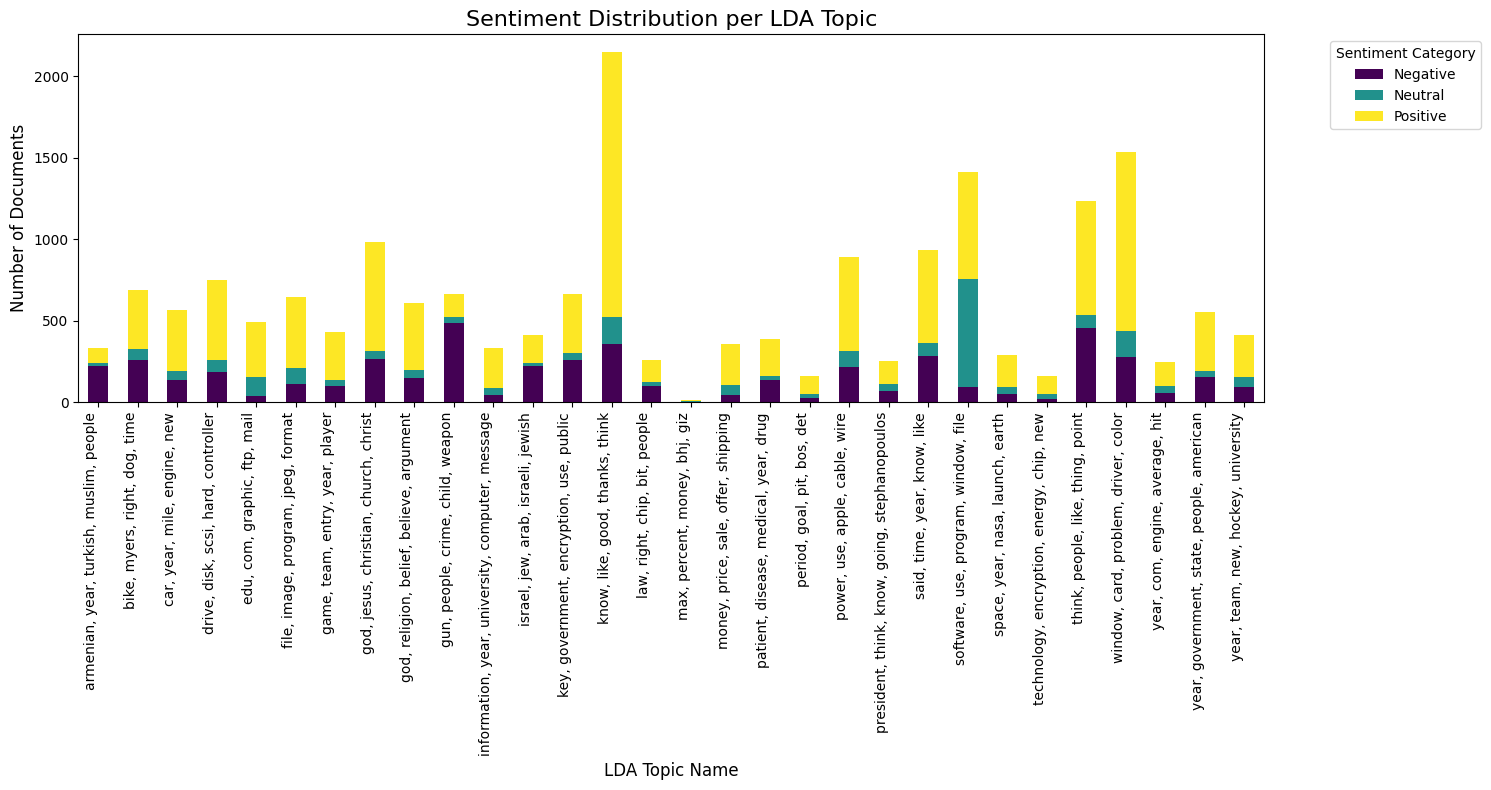

In [37]:
# Visualize sentiment distribution per LDA topic
plt.figure(figsize=(15, 8))
sentiment_distribution_lda.plot(kind='bar', stacked=True, colormap='viridis', figsize=(15, 8))
plt.title('Sentiment Distribution per LDA Topic', fontsize=16)
plt.xlabel('LDA Topic Name', fontsize=12)
plt.ylabel('Number of Documents', fontsize=12)
plt.xticks(rotation=90, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Sentiment Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [38]:
print("\n--- Method 3 (Bonus): Weighted by Topic Probability ---")

# 'lda_output' already contains the soft assignments (document-topic probabilities)
doc_topic_probs = lda_output

# Ensure compound_sentiment is a numpy array for matrix multiplication
compound_sentiment_array = dataset['compound_sentiment'].values

# Calculate weighted topic sentiment
topic_sentiment_weighted = (doc_topic_probs.T @ compound_sentiment_array) / doc_topic_probs.sum(axis=0)

# Create a Series for better readability, mapping to topic names
weighted_topic_sentiment_series = pd.Series(topic_sentiment_weighted, index=list(lda_topic_names_map.values()))

print("Weighted Average Compound Sentiment per LDA Topic (using soft assignments):")
print(weighted_topic_sentiment_series.sort_values(ascending=False))


--- Method 3 (Bonus): Weighted by Topic Probability ---
Weighted Average Compound Sentiment per LDA Topic (using soft assignments):
software, use, program, window, file                0.454515
know, like, good, thanks, think                     0.405667
information, year, university, computer, message    0.389376
money, price, sale, offer, shipping                 0.383195
edu, com, graphic, ftp, mail                        0.381754
window, card, problem, driver, color                0.361436
period, goal, pit, bos, det                         0.355225
file, image, program, jpeg, format                  0.348848
technology, encryption, energy, chip, new           0.345318
game, team, entry, year, player                     0.336591
god, jesus, christian, church, christ               0.329546
space, year, nasa, launch, earth                    0.325544
drive, disk, scsi, hard, controller                 0.301526
power, use, apple, cable, wire                      0.300387
year, team, n

#Saving models

In [39]:
import joblib
import pickle
import os

# Define a directory to save the assets
output_dir = 'model_assets'
os.makedirs(output_dir, exist_ok=True)

print(f"\nSaving assets to: {output_dir}/")

# 1. Save the clean_text function
with open(os.path.join(output_dir, 'clean_text_function.pkl'), 'wb') as f:
    pickle.dump(clean_text, f)
print("Saved clean_text_function.pkl")

# 2. Save the CountVectorizer
joblib.dump(count_vectorizer, os.path.join(output_dir, 'count_vectorizer.joblib'))
print("Saved count_vectorizer.joblib")

# 3. Save the LDA model
joblib.dump(lda, os.path.join(output_dir, 'lda_model.joblib'))
print("Saved lda_model.joblib")

# 4. Save the TfidfVectorizer
joblib.dump(tfidf_vectorizer, os.path.join(output_dir, 'tfidf_vectorizer.joblib'))
print("Saved tfidf_vectorizer.joblib")

# 5. Save the NMF model
joblib.dump(nmf, os.path.join(output_dir, 'nmf_model.joblib'))
print("Saved nmf_model.joblib")

# 6. Save the SentimentIntensityAnalyzer
with open(os.path.join(output_dir, 'sentiment_analyzer.pkl'), 'wb') as f:
    pickle.dump(sia, f)
print("Saved sentiment_analyzer.pkl")

# 7. Save LDA topic names map
with open(os.path.join(output_dir, 'lda_topic_names_map.pkl'), 'wb') as f:
    pickle.dump(lda_topic_names_map, f)
print("Saved lda_topic_names_map.pkl")

# 8. Save NMF topic names map
with open(os.path.join(output_dir, 'nmf_topic_names_map.pkl'), 'wb') as f:
    pickle.dump(nmf_topic_names_map, f)
print("Saved nmf_topic_names_map.pkl")

# 9. Save LabelEncoder
joblib.dump(label_encoder, os.path.join(output_dir, 'label_encoder.joblib'))
print("Saved label_encoder.joblib")

print("\nAll specified assets have been saved.")

# Example of how to load them back:
# loaded_clean_text = joblib.load(os.path.join(output_dir, 'clean_text_function.pkl'))
# loaded_count_vectorizer = joblib.load(os.path.join(output_dir, 'count_vectorizer.joblib'))


Saving assets to: model_assets/
Saved clean_text_function.pkl
Saved count_vectorizer.joblib
Saved lda_model.joblib
Saved tfidf_vectorizer.joblib
Saved nmf_model.joblib
Saved sentiment_analyzer.pkl
Saved lda_topic_names_map.pkl
Saved nmf_topic_names_map.pkl
Saved label_encoder.joblib

All specified assets have been saved.


In [40]:
simplified_lda_topic_names_map = {
    0: 'Software',
    1: 'Bikes',
    2: 'Space',
    3: 'Power',
    4: 'Encryption',
    5: 'Hockey',
    6: 'Politics',
    7: 'Government',
    8: 'Money',
    9: 'Religion',
    10: 'Computers',
    11: 'Guns',
    12: 'General',
    13: 'Sales',
    14: 'Disk Drive',
    15: 'Files',
    16: 'Conversation',
    17: 'Medical',
    18: 'Technology',
    19: 'Mideast',
    20: 'Sports',
    21: 'Christianity',
    22: 'Automotive',
    23: 'Gaming',
    24: 'Queries',
    25: 'Cars',
    26: 'Law',
    27: 'Armenian Conflict',
    28: 'Internet',
    29: 'Windows'
}

print("Simplified LDA topic names map created.")

# Create a new DataFrame copy to avoid modifying the existing 'df'
df_with_both_topic_names = df.copy()

# Add a new column for the simplified LDA topic names
df_with_both_topic_names['lda_simplified_topic_name'] = df_with_both_topic_names['lda_categorical_topic'].map(simplified_lda_topic_names_map)

# # Add a new column for the verbose (original detailed) LDA topic names
# df_with_both_topic_names['lda_verbose_topic_name'] = df_with_both_topic_names['lda_categorical_topic'].map(lda_topic_names_map)

# Optionally, remove the original 'lda_topic_name' if it was present and not needed
# if 'lda_topic_name' in df_with_both_topic_names.columns:
#     df_with_both_topic_names.drop(columns=['lda_topic_name'], inplace=True)

print("New DataFrame 'df_with_both_topic_names' created with both simplified and verbose LDA topic names.")
df_with_both_topic_names

Simplified LDA topic names map created.
New DataFrame 'df_with_both_topic_names' created with both simplified and verbose LDA topic names.


,text,summary,category_name,lda_categorical_topic,lda_topic_name,lda_simplified_topic_name
0,sure bashers pen fan pretty confused lack kind...,I am sure some bashers of Pens fans are pretty...,"rec, sport, hockey",23,"game, team, entry, year, player",Gaming
1,brother market high performance video card sup...,My brother is in the market for a high-perform...,"comp, sys, ibm, pc, hardware",29,"window, card, problem, driver, color",Windows
2,finally said dream mediterranean new area grea...,Finally you said what you dream about. Mediter...,"talk, politics, mideast",27,"armenian, year, turkish, muslim, people",Armenian Conflict
3,think scsi card dma transfer disk scsi card dm...,Think! It's the SCSI card doing the DMA transf...,"comp, sys, ibm, pc, hardware",14,"drive, disk, scsi, hard, controller",Disk Drive
4,old jasmine drive use new system understanding...,1) I have an old Jasmine drive which I cannot ...,"comp, sys, mac, hardware",14,"drive, disk, scsi, hard, controller",Disk Drive
...,...,...,...,...,...,...
18841,nyeda cnsvax uwec edu david nye neurology cons...,DN> From: nyeda@cnsvax.uwec.edu (David Nye) DN...,"sci, med",1,"bike, myers, right, dog, time",Bikes
18842,isolated ground recepticles usually unusual co...,Not in isolated ground recepticles (usually an...,"sci, electronics",3,"power, use, apple, cable, wire",Power
18843,installed cpu clone motherboard tried mounting...,I just installed a DX2-66 CPU in a clone mothe...,"comp, sys, ibm, pc, hardware",3,"power, use, apple, cable, wire",Power
18844,wouldn require hyper sphere space point specif...,Wouldn't this require a hyper-sphere. In 3-spa...,"comp, graphics",12,"think, people, like, thing, point",General


In [41]:
df

,text,summary,category_name,lda_categorical_topic,lda_topic_name
0,sure bashers pen fan pretty confused lack kind...,I am sure some bashers of Pens fans are pretty...,"rec, sport, hockey",23,"game, team, entry, year, player"
1,brother market high performance video card sup...,My brother is in the market for a high-perform...,"comp, sys, ibm, pc, hardware",29,"window, card, problem, driver, color"
2,finally said dream mediterranean new area grea...,Finally you said what you dream about. Mediter...,"talk, politics, mideast",27,"armenian, year, turkish, muslim, people"
3,think scsi card dma transfer disk scsi card dm...,Think! It's the SCSI card doing the DMA transf...,"comp, sys, ibm, pc, hardware",14,"drive, disk, scsi, hard, controller"
4,old jasmine drive use new system understanding...,1) I have an old Jasmine drive which I cannot ...,"comp, sys, mac, hardware",14,"drive, disk, scsi, hard, controller"
...,...,...,...,...,...
18841,nyeda cnsvax uwec edu david nye neurology cons...,DN> From: nyeda@cnsvax.uwec.edu (David Nye) DN...,"sci, med",1,"bike, myers, right, dog, time"
18842,isolated ground recepticles usually unusual co...,Not in isolated ground recepticles (usually an...,"sci, electronics",3,"power, use, apple, cable, wire"
18843,installed cpu clone motherboard tried mounting...,I just installed a DX2-66 CPU in a clone mothe...,"comp, sys, ibm, pc, hardware",3,"power, use, apple, cable, wire"
18844,wouldn require hyper sphere space point specif...,Wouldn't this require a hyper-sphere. In 3-spa...,"comp, graphics",12,"think, people, like, thing, point"


In [42]:
dataset

,text,summary,category_name,lda_categorical_topic,lda_topic_name,sentiment_scores,compound_sentiment,sentiment_category
0,sure bashers pen fan pretty confused lack kind...,I am sure some bashers of Pens fans are pretty...,"rec, sport, hockey",23,"game, team, entry, year, player","{'neg': 0.28, 'neu': 0.424, 'pos': 0.296, 'com...",0.1531,Positive
1,brother market high performance video card sup...,My brother is in the market for a high-perform...,"comp, sys, ibm, pc, hardware",29,"window, card, problem, driver, color","{'neg': 0.035, 'neu': 0.759, 'pos': 0.206, 'co...",0.7430,Positive
2,finally said dream mediterranean new area grea...,Finally you said what you dream about. Mediter...,"talk, politics, mideast",27,"armenian, year, turkish, muslim, people","{'neg': 0.362, 'neu': 0.51, 'pos': 0.128, 'com...",-0.9876,Negative
3,think scsi card dma transfer disk scsi card dm...,Think! It's the SCSI card doing the DMA transf...,"comp, sys, ibm, pc, hardware",14,"drive, disk, scsi, hard, controller","{'neg': 0.0, 'neu': 0.808, 'pos': 0.192, 'comp...",0.9100,Positive
4,old jasmine drive use new system understanding...,1) I have an old Jasmine drive which I cannot ...,"comp, sys, mac, hardware",14,"drive, disk, scsi, hard, controller","{'neg': 0.0, 'neu': 0.911, 'pos': 0.089, 'comp...",0.5574,Positive
...,...,...,...,...,...,...,...,...
18841,nyeda cnsvax uwec edu david nye neurology cons...,DN> From: nyeda@cnsvax.uwec.edu (David Nye) DN...,"sci, med",1,"bike, myers, right, dog, time","{'neg': 0.124, 'neu': 0.676, 'pos': 0.201, 'co...",0.8479,Positive
18842,isolated ground recepticles usually unusual co...,Not in isolated ground recepticles (usually an...,"sci, electronics",3,"power, use, apple, cable, wire","{'neg': 0.333, 'neu': 0.667, 'pos': 0.0, 'comp...",-0.6705,Negative
18843,installed cpu clone motherboard tried mounting...,I just installed a DX2-66 CPU in a clone mothe...,"comp, sys, ibm, pc, hardware",3,"power, use, apple, cable, wire","{'neg': 0.05, 'neu': 0.743, 'pos': 0.206, 'com...",0.8126,Positive
18844,wouldn require hyper sphere space point specif...,Wouldn't this require a hyper-sphere. In 3-spa...,"comp, graphics",12,"think, people, like, thing, point","{'neg': 0.129, 'neu': 0.871, 'pos': 0.0, 'comp...",-0.4767,Negative


In [43]:
import os

output_dir = 'processed_data'
os.makedirs(output_dir, exist_ok=True)

# Save the final processed dataset (after sentiment analysis) to a CSV file
dataset.to_csv(os.path.join(output_dir, 'processed_newsgroups_dataset_after_sentiment.csv'), index=False)
print(f"Processed dataset (after sentiment analysis) saved to {os.path.join(output_dir, 'processed_newsgroups_dataset_after_sentiment.csv')}")

# Save the dataset before sentiment analysis
df.to_csv(os.path.join(output_dir, 'processed_newsgroups_dataset_before_sentiment.csv'), index=False)
print(f"Processed dataset (before sentiment analysis) saved to {os.path.join(output_dir, 'processed_newsgroups_dataset_before_sentiment.csv')}")

# Save dataset with Topic Names
df_with_both_topic_names.to_csv(os.path.join(output_dir, 'processed_newsgroups_dataset_with_topic_names.csv'), index=False)
print(f"Processed dataset (with Topic Names) saved to {os.path.join(output_dir, 'processed_newsgroups_dataset_with_topic_names.csv')}")

Processed dataset (after sentiment analysis) saved to processed_data/processed_newsgroups_dataset_after_sentiment.csv
Processed dataset (before sentiment analysis) saved to processed_data/processed_newsgroups_dataset_before_sentiment.csv
Processed dataset (with Topic Names) saved to processed_data/processed_newsgroups_dataset_with_topic_names.csv
